CUSTOMER SUPPORT DATA ANALYSIS & TICKET RESOLUTION

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from wordcloud import WordCloud
import re
import string

nltk.download('stopwords')
from nltk.corpus import stopwords

In [ ]:
# Load the dataset
df=pd.read_csv("Customer Support Ticket Dataset.csv")

In [3]:
# Print first few rows
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,22-03-2021,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,01-06-2023 12:15,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,22-05-2021,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,01-06-2023 16:45,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,14-07-2020,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,01-06-2023 11:14,01-06-2023 18:05,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,13-11-2020,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,01-06-2023 07:29,01-06-2023 01:57,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,04-02-2020,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,01-06-2023 00:12,01-06-2023 19:53,1.0


In [4]:
# Perform initial exploratory data analysis (EDA)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [5]:
df.describe()

,Ticket ID,Customer Age,Customer Satisfaction Rating
count,8469.000000,8469.000000,2769.000000
mean,4235.000000,44.026804,2.991333
std,2444.934048,15.296112,1.407016
min,1.000000,18.000000,1.000000
25%,2118.000000,31.000000,2.000000
50%,4235.000000,44.000000,3.000000
75%,6352.000000,57.000000,4.000000
max,8469.000000,70.000000,5.000000


In [6]:
# Print column names
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

In [ ]:
# Replace placeholder text
df['Ticket Description']=df['Ticket Description'].str.replace(r'\{.*?\}', '', regex=True)

In [8]:
print(df['Ticket Description'])

0       I'm having an issue with the . Please assist.\...
1       I'm having an issue with the . Please assist.\...
2       I'm facing a problem with my . The  is not tur...
3       I'm having an issue with the . Please assist.\...
4       I'm having an issue with the . Please assist.\...
                              ...                        
8464    My  is making strange noises and not functioni...
8465    I'm having an issue with the . Please assist.\...
8466    I'm having an issue with the . Please assist. ...
8467    I'm having an issue with the . Please assist. ...
8468    There seems to be a hardware problem with my ....
Name: Ticket Description, Length: 8469, dtype: object


In [ ]:
# Clean text function
def clean_text(text):
    text=text.lower()
    text=re.sub(r'\d+', '', text)  # remove numbers
    text=text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text=text.strip()
    text=' '.join(word for word in text.split() if word not in stopwords.words('english'))
    return text

In [ ]:
df['cleaned_description']=df['Ticket Description'].apply(clean_text)
df[['Ticket Description', 'cleaned_description']].head()

,Ticket Description,cleaned_description
0,I'm having an issue with the . Please assist.\...,im issue please assist billing zip code apprec...
1,I'm having an issue with the . Please assist.\...,im issue please assist need change existing pr...
2,I'm facing a problem with my . The is not tur...,im facing problem turning working fine yesterd...
3,I'm having an issue with the . Please assist.\...,im issue please assist problem youre intereste...
4,I'm having an issue with the . Please assist.\...,im issue please assist note seller responsible...


In [ ]:
# Convert text to TF-IDF features
tfidf=TfidfVectorizer(max_df=0.9, min_df=10)
X=tfidf.fit_transform(df['cleaned_description'])

In [ ]:
# KMeans Clustering to group similar issues
kmeans=KMeans(n_clusters=5, random_state=42)
df['Issue Cluster'] = kmeans.fit_predict(X)

In [13]:
df['Issue Cluster']

0       4
1       4
2       4
3       3
4       4
       ..
8464    3
8465    4
8466    1
8467    2
8468    1
Name: Issue Cluster, Length: 8469, dtype: int32

In [ ]:
# Top keywords per cluster
def get_top_keywords(n_terms=10):
    order_centroids=kmeans.cluster_centers_.argsort()[:, ::-1]
    terms=tfidf.get_feature_names_out()
    for i in range(5):
        print(f"\nCluster {i} keywords:")
        for ind in order_centroids[i, :n_terms]:
            print(terms[ind])
get_top_keywords()

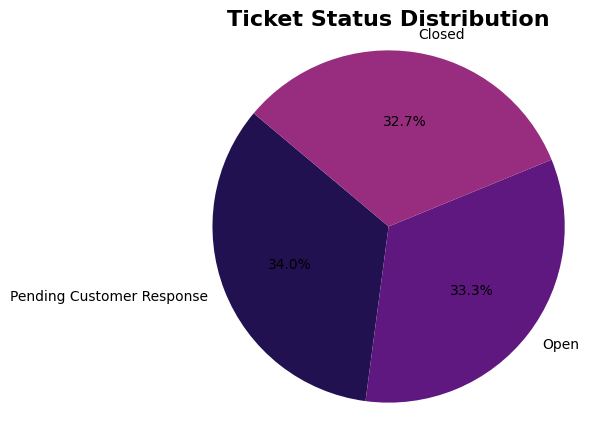

In [47]:
#Ticket Status Distribution
ticket_status_distribution=df['Ticket Status'].value_counts()
plt.figure(figsize=(5,5))
plt.pie(ticket_status_distribution, labels=ticket_status_distribution.index, autopct='%1.1f%%', colors=sns.color_palette('magma'), startangle=140)
plt.title('Ticket Status Distribution', weight='bold', fontsize=16)
plt.axis('equal')
plt.show()

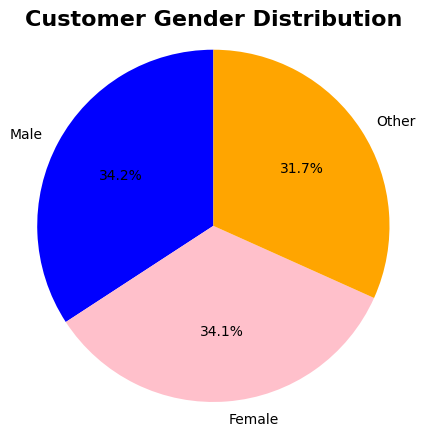

In [48]:
#Customer Gender Distribution
customer_gender_distribution=df['Customer Gender'].value_counts()
color_list=['blue', 'pink', 'orange']
plt.figure(figsize=(5, 5))
plt.pie(customer_gender_distribution, labels=customer_gender_distribution.index, autopct='%1.1f%%', colors=color_list, startangle=90)
plt.title('Customer Gender Distribution', weight='bold', fontsize=16)
plt.axis('equal')
plt.show()

In [ ]:
# Convert time columns
df['First Response Time']=pd.to_datetime(df['First Response Time'], errors='coerce')
df['Time to Resolution']=pd.to_datetime(df['Time to Resolution'], errors='coerce')

In [ ]:
# Calculate response delay (hours)
df['Response Delay (hrs)']=(df['Time to Resolution'] - df['First Response Time']).dt.total_seconds() / 3600

In [19]:
df.head(2)

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,cleaned_description,Issue Cluster,Response Delay (hrs)
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,22-03-2021,Technical issue,Product setup,I'm having an issue with the . Please assist.\...,Pending Customer Response,NaN,Critical,Social media,2023-01-06 12:15:00,NaT,NaN,im issue please assist billing zip code apprec...,4,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,22-05-2021,Technical issue,Peripheral compatibility,I'm having an issue with the . Please assist.\...,Pending Customer Response,NaN,Critical,Chat,2023-01-06 16:45:00,NaT,NaN,im issue please assist need change existing pr...,4,NaN


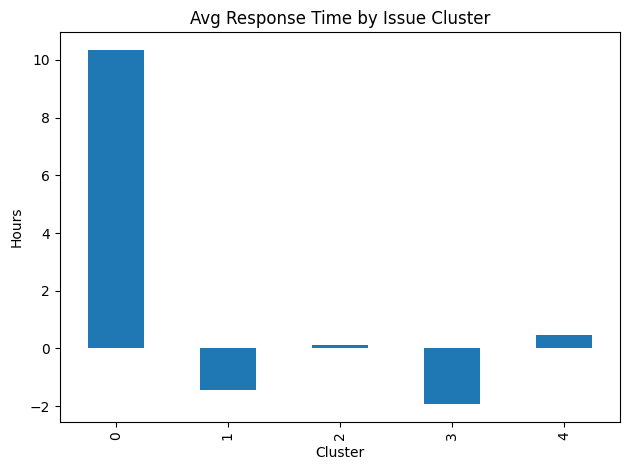

In [46]:
# Average response time by issue cluster
avg_response_by_cluster=df.groupby('Issue Cluster')['Response Delay (hrs)'].mean().dropna()
avg_response_by_cluster.plot(kind='bar', title='Avg Response Time by Issue Cluster', ylabel='Hours', xlabel='Cluster')
plt.tight_layout()
plt.show()

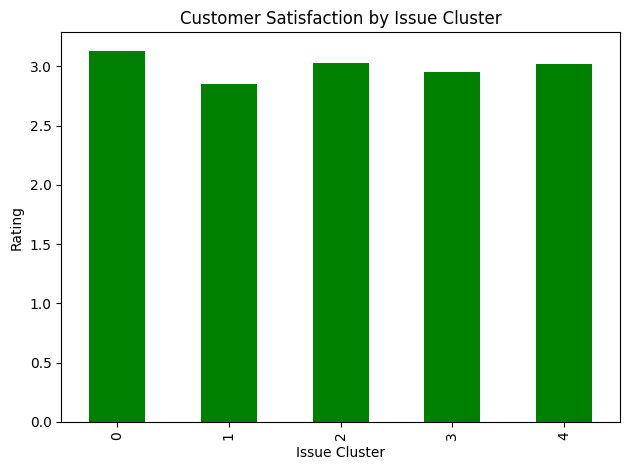

In [49]:
# Average satisfaction rating by issue cluster
satisfaction_by_cluster=df.groupby('Issue Cluster')['Customer Satisfaction Rating'].mean().dropna()
satisfaction_by_cluster.plot(kind='bar', color='green', title='Customer Satisfaction by Issue Cluster', ylabel='Rating')
plt.tight_layout()
plt.show()

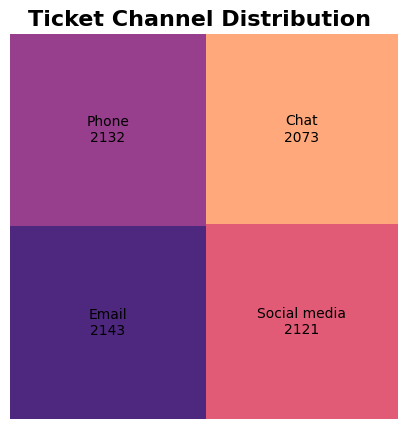

In [50]:
# Data
ticket_channel_distribution=df['Ticket Channel'].value_counts()
labels=[f"{label}\n{count}" for label, count in zip(ticket_channel_distribution.index, ticket_channel_distribution.values)]
sizes=ticket_channel_distribution.values
colors=sns.color_palette('magma', len(sizes))

# Ticket Channel Distribution
plt.figure(figsize=(5, 5))
squarify.plot(sizes=sizes, label=labels, color=colors, alpha=0.9, text_kwargs={'fontsize': 10})
plt.title('Ticket Channel Distribution ', weight='bold', fontsize=16)
plt.axis('off')
plt.show()

In [ ]:
# Summary of clusters, delays, and satisfaction
summary=df.groupby('Issue Cluster').agg({
    'Ticket ID': 'count',
    'Response Delay (hrs)': 'mean',
    'Customer Satisfaction Rating': 'mean'
}).rename(columns={'Ticket ID': 'Tickets Count'})
summary

,Tickets Count,Response Delay (hrs),Customer Satisfaction Rating
Issue Cluster,,,
0,655,10.338047,3.130841
1,1430,-1.454167,2.851695
2,695,0.107175,3.029787
3,1152,-1.927562,2.955182
4,4537,0.481019,3.018109


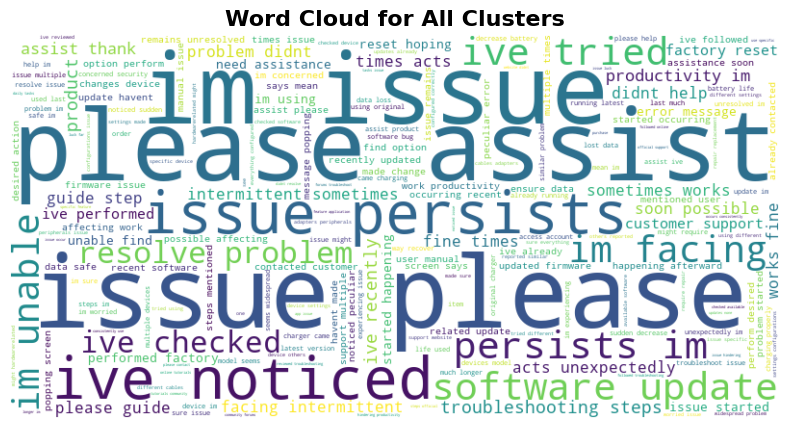

In [51]:
# Word cloud for all cluster
cluster_text=" ".join(df['cleaned_description'])
wordcloud=WordCloud(width=800, height=400, background_color='white').generate(cluster_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for All Clusters", weight='bold', fontsize=16)
plt.show()

In [80]:
# Save Processed Data
df.to_csv("Processed Customer Support Ticket Dataset.csv", index=False)
print("\n Processed data saved to 'Processed Customer Support Ticket Dataset.csv'")


 Processed data saved to 'Processed Customer Support Ticket Dataset.csv'
